# Task 1: Vectorized Multi-Layer Perceptron (MLP) Forward & Backward Pass from Scratch

## Objective

Implement a fully connected Multi-Layer Perceptron (MLP) from first principles using only NumPy.

This notebook demonstrates:

- Arbitrary hidden-layer dimensions
- Batch-wise vectorized forward propagation
- ReLU activation and derivative
- Softmax output
- Categorical cross-entropy loss
- Manual backward propagation
- Layer-wise local Jacobians
- Raw 3D Jacobian transformations
- Manual gradient-descent updates
- Numerical gradient checking
- Model training and evaluation

No PyTorch autograd, TensorFlow, Keras, or other automatic differentiation frameworks are used.

## Mathematical Foundation

For layer \(l\):

\[
Z^{[l]} = A^{[l-1]}W^{[l]} + b^{[l]}
\]

\[
A^{[l]} = f(Z^{[l]})
\]

For the output layer:

\[
\hat{Y} = Softmax(Z^{[L]})
\]

Categorical cross-entropy:

\[
L = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{C}
Y_{ik}\log(\hat{Y}_{ik})
\]

For Softmax combined with cross-entropy:

\[
dZ^{[L]} = \hat{Y} - Y
\]

For each layer:

\[
dW^{[l]} =
\frac{1}{m}(A^{[l-1]})^T dZ^{[l]}
\]

\[
db^{[l]} =
\frac{1}{m}\sum_i dZ_i^{[l]}
\]

\[
dA^{[l-1]} =
dZ^{[l]}(W^{[l]})^T
\]

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy version:", np.__version__)

NumPy version: 2.0.2


# Dataset Preparation

A synthetic three-class classification dataset is created using NumPy.

The dataset contains:

- 4 input features
- 3 output classes
- Training and testing samples
- One-hot encoded target labels

The dataset is used to demonstrate the complete MLP forward and backward passes.

In [8]:
# Number of samples and features
m = 1500
input_dim = 4
num_classes = 3

samples_per_class = m // num_classes

# Class centers
centers = np.array([
    [-2.0, -2.0,  1.0,  1.0],
    [ 2.0, -1.0, -1.0,  2.0],
    [ 0.0,  2.0,  2.0, -1.0]
])

X_parts = []
labels = []

# Generate three classes
for class_id in range(num_classes):

    class_samples = (
        np.random.randn(samples_per_class, input_dim) * 0.8
        + centers[class_id]
    )

    X_parts.append(class_samples)
    labels.extend([class_id] * samples_per_class)

X = np.vstack(X_parts)
y = np.array(labels)

# Shuffle
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

# Standardization
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

# One-hot encoding
Y = np.zeros((len(y), num_classes))
Y[np.arange(len(y)), y] = 1

# Train-test split
split = int(0.8 * len(X))

X_train = X[:split]
Y_train = Y[:split]

X_test = X[split:]
Y_test = Y[split:]

print("Complete dataset:", X.shape)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Number of classes:", num_classes)

Complete dataset: (1500, 4)
Training data: (1200, 4)
Testing data: (300, 4)
Number of classes: 3


# Activation Functions, Softmax and Loss

ReLU is used in the hidden layers:

\[
ReLU(z) = max(0,z)
\]

Its derivative is:

\[
ReLU'(z) =
\begin{cases}
1 & z > 0\\
0 & z \leq 0
\end{cases}
\]

The output layer uses Softmax:

\[
Softmax(z_i) =
\frac{e^{z_i}}{\sum_j e^{z_j}}
\]

A numerically stable version is used by subtracting the maximum value before calculating the exponential.

The loss function is categorical cross-entropy.

In [9]:
# ============================================================
# ReLU
# ============================================================

def relu(Z):
    return np.maximum(0, Z)


def relu_derivative(Z):
    return (Z > 0).astype(float)


# ============================================================
# Softmax
# ============================================================

def softmax(Z):

    # Numerical stability
    shifted_Z = Z - np.max(
        Z,
        axis=1,
        keepdims=True
    )

    exp_Z = np.exp(shifted_Z)

    return exp_Z / (
        np.sum(
            exp_Z,
            axis=1,
            keepdims=True
        ) + 1e-12
    )


# ============================================================
# Cross-Entropy Loss
# ============================================================

def cross_entropy(Y_true, Y_pred):

    epsilon = 1e-12

    Y_pred = np.clip(
        Y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.sum(
        Y_true * np.log(Y_pred)
    ) / Y_true.shape[0]

    return loss


# Test Softmax
test_Z = np.array([
    [2.0, 1.0, 0.5],
    [0.1, 2.0, 1.5]
])

test_probabilities = softmax(test_Z)

print("Softmax:")
print(test_probabilities)

print("\nProbability sums:")
print(test_probabilities.sum(axis=1))

Softmax:
[[0.62853172 0.2312239  0.14024438]
 [0.08517094 0.56944389 0.34538518]]

Probability sums:
[1. 1.]


# MLP Parameter Initialization

The network supports arbitrary hidden-layer dimensions.

For example:

\[
[4,16,32,16,3]
\]

means:

```text
Input Layer     : 4 neurons
Hidden Layer 1  : 16 neurons
Hidden Layer 2  : 32 neurons
Hidden Layer 3  : 16 neurons
Output Layer    : 3 neurons

In [10]:
# ============================================================
# Parameter Initialization
# ============================================================

def initialize_parameters(layer_sizes):

    parameters = {}

    for l in range(1, len(layer_sizes)):

        input_units = layer_sizes[l - 1]
        output_units = layer_sizes[l]

        # He initialization
        parameters[f"W{l}"] = (
            np.random.randn(
                input_units,
                output_units
            )
            * np.sqrt(2.0 / input_units)
        )

        # Bias
        parameters[f"b{l}"] = np.zeros(
            (1, output_units)
        )

    return parameters


# Arbitrary architecture
layer_sizes = [
    input_dim,
    16,
    32,
    16,
    num_classes
]

parameters = initialize_parameters(
    layer_sizes
)

print("Architecture:", layer_sizes)

for name, value in parameters.items():
    print(name, ":", value.shape)

Architecture: [4, 16, 32, 16, 3]
W1 : (4, 16)
b1 : (1, 16)
W2 : (16, 32)
b2 : (1, 32)
W3 : (32, 16)
b3 : (1, 16)
W4 : (16, 3)
b4 : (1, 3)


# Vectorized Forward Propagation

For every layer:

\[
Z^{[l]} = A^{[l-1]}W^{[l]} + b^{[l]}
\]

For hidden layers:

\[
A^{[l]} = ReLU(Z^{[l]})
\]

For the output layer:

\[
A^{[L]} = Softmax(Z^{[L]})
\]

The entire batch is processed simultaneously using matrix multiplication.

No loop is performed over individual samples.

In [11]:
# ============================================================
# Vectorized Forward Propagation
# ============================================================

def forward(X, parameters):

    activations = [X]
    pre_activations = []

    A = X

    number_of_layers = len(parameters) // 2

    for l in range(1, number_of_layers + 1):

        W = parameters[f"W{l}"]
        b = parameters[f"b{l}"]

        # Linear transformation
        Z = A @ W + b

        pre_activations.append(Z)

        # Hidden layers
        if l < number_of_layers:

            A = relu(Z)

        # Output layer
        else:

            A = softmax(Z)

        activations.append(A)

    return A, activations, pre_activations


# Test forward propagation
X_batch = X_train[:32]

Y_pred, activations, pre_activations = forward(
    X_batch,
    parameters
)

print("Input shape:", X_batch.shape)
print("Output shape:", Y_pred.shape)

print("\nFirst prediction:")
print(Y_pred[0])

print("\nProbability sum:")
print(Y_pred[0].sum())

Input shape: (32, 4)
Output shape: (32, 3)

First prediction:
[0.26056893 0.70363221 0.03579886]

Probability sum:
0.9999999999992961


# Local Jacobians and 3D Matrix Transformations

A Jacobian represents the derivatives of a vector output with respect to a vector input.

For ReLU:

\[
J_{ReLU} = diag(ReLU'(z))
\]

For Softmax:

\[
J_{Softmax}
=
diag(s) - ss^T
\]

For a batch, the Jacobians are stored as a 3D tensor:

\[
(batch\_size, neurons, neurons)
\]

This explicitly demonstrates the required raw 3D matrix transformation.

For Softmax, each sample has its own Jacobian matrix.

In [12]:
# ============================================================
# 3D ReLU Jacobian
# ============================================================

def relu_jacobian_3d(Z):

    batch_size, neurons = Z.shape

    J = np.zeros(
        (batch_size, neurons, neurons)
    )

    derivatives = relu_derivative(Z)

    for i in range(batch_size):

        J[i] = np.diag(
            derivatives[i]
        )

    return J


# ============================================================
# 3D Softmax Jacobian
# ============================================================

def softmax_jacobian_3d(S):

    batch_size, classes = S.shape

    J = np.zeros(
        (batch_size, classes, classes)
    )

    for i in range(batch_size):

        s = S[i]

        J[i] = (
            np.diag(s)
            - np.outer(s, s)
        )

    return J


# Create example Jacobians
example_Z = pre_activations[0][:5]
example_S = activations[-1][:5]

relu_J = relu_jacobian_3d(
    example_Z
)

softmax_J = softmax_jacobian_3d(
    example_S
)

print("ReLU Jacobian shape:")
print(relu_J.shape)

print("\nSoftmax Jacobian shape:")
print(softmax_J.shape)

print("\nExample ReLU Jacobian:")
print(relu_J[0])

print("\nExample Softmax Jacobian:")
print(softmax_J[0])

ReLU Jacobian shape:
(5, 16, 16)

Softmax Jacobian shape:
(5, 3, 3)

Example ReLU Jacobian:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Example Softmax Jacobian:
[[ 0.19267276 -0.18334469 -0.00932807]
 [-0.18334469  0.20853392

# Vectorized Backward Propagation

For the final Softmax + Cross-Entropy layer:

\[
dZ^{[L]} = \hat{Y} - Y
\]

For each layer:

\[
dW^{[l]} =
\frac{1}{m}
(A^{[l-1]})^T dZ^{[l]}
\]

\[
db^{[l]} =
\frac{1}{m}
\sum_i dZ_i^{[l]}
\]

The gradient passed to the previous layer is:

\[
dA^{[l-1]} =
dZ^{[l]}(W^{[l]})^T
\]

For ReLU:

\[
dZ^{[l]} =
dA^{[l]} \odot ReLU'(Z^{[l]})
\]

The implementation below performs the backward pass manually without automatic differentiation.

In [13]:
# ============================================================
# Vectorized Backward Propagation
# ============================================================

def backward(
    Y_true,
    Y_pred,
    activations,
    pre_activations,
    parameters
):

    gradients = {}

    number_of_layers = len(parameters) // 2

    m = Y_true.shape[0]

    # --------------------------------------------------------
    # Output layer
    # Softmax + Cross Entropy
    # --------------------------------------------------------

    dZ = (
        Y_pred - Y_true
    ) / m

    # --------------------------------------------------------
    # Backward through all layers
    # --------------------------------------------------------

    for l in range(
        number_of_layers,
        0,
        -1
    ):

        A_previous = activations[l - 1]

        W = parameters[f"W{l}"]

        # Gradient with respect to weights
        gradients[f"dW{l}"] = (
            A_previous.T @ dZ
        )

        # Gradient with respect to bias
        gradients[f"db{l}"] = (
            np.sum(
                dZ,
                axis=0,
                keepdims=True
            )
        )

        # Propagate to previous layer
        if l > 1:

            dA_previous = (
                dZ @ W.T
            )

            dZ = (
                dA_previous
                * relu_derivative(
                    pre_activations[l - 2]
                )
            )

    return gradients


# Test backward propagation
Y_batch = Y_train[:32]

predictions, acts, zs = forward(
    X_batch,
    parameters
)

loss = cross_entropy(
    Y_batch,
    predictions
)

gradients = backward(
    Y_batch,
    predictions,
    acts,
    zs,
    parameters
)

print("Loss:", loss)

print("\nGradient shapes:")

for name, value in gradients.items():

    print(
        name,
        ":",
        value.shape
    )

Loss: 0.9153927370410031

Gradient shapes:
dW4 : (16, 3)
db4 : (1, 3)
dW3 : (32, 16)
db3 : (1, 16)
dW2 : (16, 32)
db2 : (1, 32)
dW1 : (4, 16)
db1 : (1, 16)


# Gradient Descent Parameter Update

The parameters are updated using gradient descent:

\[
W^{[l]} =
W^{[l]} - \eta dW^{[l]}
\]

\[
b^{[l]} =
b^{[l]} - \eta db^{[l]}
\]

where \(\eta\) is the learning rate.

The update is implemented manually without using an optimizer.

In [14]:
# ============================================================
# Manual Gradient Descent
# ============================================================

def update_parameters(
    parameters,
    gradients,
    learning_rate
):

    number_of_layers = len(parameters) // 2

    for l in range(
        1,
        number_of_layers + 1
    ):

        parameters[f"W{l}"] -= (
            learning_rate
            * gradients[f"dW{l}"]
        )

        parameters[f"b{l}"] -= (
            learning_rate
            * gradients[f"db{l}"]
        )

    return parameters

# Training the MLP

The training process consists of:

1. Mini-batch selection
2. Forward propagation
3. Cross-entropy loss calculation
4. Backward propagation
5. Gradient calculation
6. Manual parameter updates

Mini-batch gradient descent is used to process the training data efficiently.

In [15]:
# ============================================================
# Training Function
# ============================================================

def train_mlp(
    X,
    Y,
    layer_sizes,
    epochs=100,
    batch_size=32,
    learning_rate=0.01
):

    parameters = initialize_parameters(
        layer_sizes
    )

    loss_history = []
    accuracy_history = []

    number_of_samples = X.shape[0]

    for epoch in range(epochs):

        # Shuffle dataset
        indices = np.random.permutation(
            number_of_samples
        )

        X_shuffled = X[indices]
        Y_shuffled = Y[indices]

        # Mini-batch training
        for start in range(
            0,
            number_of_samples,
            batch_size
        ):

            end = min(
                start + batch_size,
                number_of_samples
            )

            X_batch = X_shuffled[
                start:end
            ]

            Y_batch = Y_shuffled[
                start:end
            ]

            # Forward pass
            Y_pred, activations, pre_activations = forward(
                X_batch,
                parameters
            )

            # Backward pass
            gradients = backward(
                Y_batch,
                Y_pred,
                activations,
                pre_activations,
                parameters
            )

            # Gradient descent
            parameters = update_parameters(
                parameters,
                gradients,
                learning_rate
            )

        # Evaluate complete training set
        train_predictions, _, _ = forward(
            X,
            parameters
        )

        loss = cross_entropy(
            Y,
            train_predictions
        )

        predicted_labels = np.argmax(
            train_predictions,
            axis=1
        )

        true_labels = np.argmax(
            Y,
            axis=1
        )

        accuracy = np.mean(
            predicted_labels == true_labels
        )

        loss_history.append(loss)
        accuracy_history.append(accuracy)

        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
        ):

            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Loss: {loss:.6f} | "
                f"Accuracy: {accuracy * 100:.2f}%"
            )

    return (
        parameters,
        loss_history,
        accuracy_history
    )

In [16]:
# ============================================================
# Train the MLP
# ============================================================

trained_parameters, loss_history, accuracy_history = train_mlp(
    X_train,
    Y_train,
    layer_sizes=layer_sizes,
    epochs=100,
    batch_size=32,
    learning_rate=0.01
)

print("\nTraining completed.")
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

print(
    "Final training accuracy:",
    accuracy_history[-1] * 100,
    "%"
)

Epoch   1/100 | Loss: 0.378172 | Accuracy: 88.92%
Epoch  10/100 | Loss: 0.041121 | Accuracy: 99.67%
Epoch  20/100 | Loss: 0.018501 | Accuracy: 99.67%
Epoch  30/100 | Loss: 0.012035 | Accuracy: 99.92%
Epoch  40/100 | Loss: 0.008975 | Accuracy: 99.92%
Epoch  50/100 | Loss: 0.007188 | Accuracy: 99.92%
Epoch  60/100 | Loss: 0.006019 | Accuracy: 99.92%
Epoch  70/100 | Loss: 0.005196 | Accuracy: 99.92%
Epoch  80/100 | Loss: 0.004580 | Accuracy: 99.92%
Epoch  90/100 | Loss: 0.004111 | Accuracy: 99.92%
Epoch 100/100 | Loss: 0.003734 | Accuracy: 99.92%

Training completed.
Initial loss: 0.3781722710295505
Final loss: 0.003734487976841566
Final training accuracy: 99.91666666666667 %


# Model Evaluation

The trained model is evaluated on the unseen test dataset.

The following metrics are calculated:

- Test loss
- Test accuracy

A training loss curve and accuracy curve are also displayed to observe the learning behavior of the MLP.

In [17]:
# ============================================================
# Test Evaluation
# ============================================================

test_predictions, _, _ = forward(
    X_test,
    trained_parameters
)

test_loss = cross_entropy(
    Y_test,
    test_predictions
)

test_predicted_labels = np.argmax(
    test_predictions,
    axis=1
)

test_true_labels = np.argmax(
    Y_test,
    axis=1
)

test_accuracy = np.mean(
    test_predicted_labels
    == test_true_labels
)

print("========== TEST RESULTS ==========")
print(
    f"Test Loss: {test_loss:.6f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

========== TEST RESULTS ==========
Test Loss: 0.004697
Test Accuracy: 100.00%


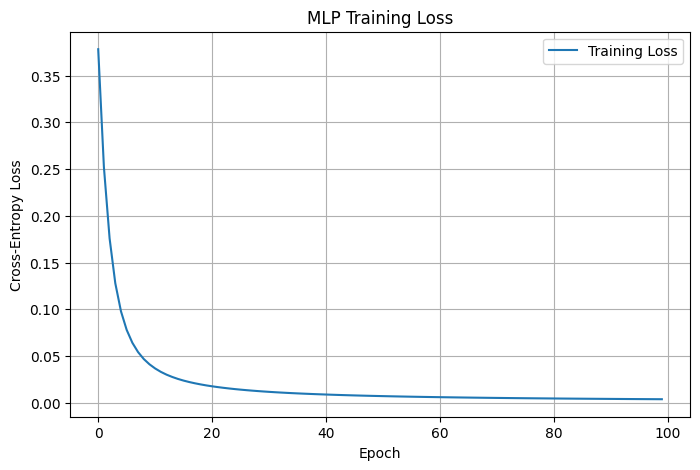

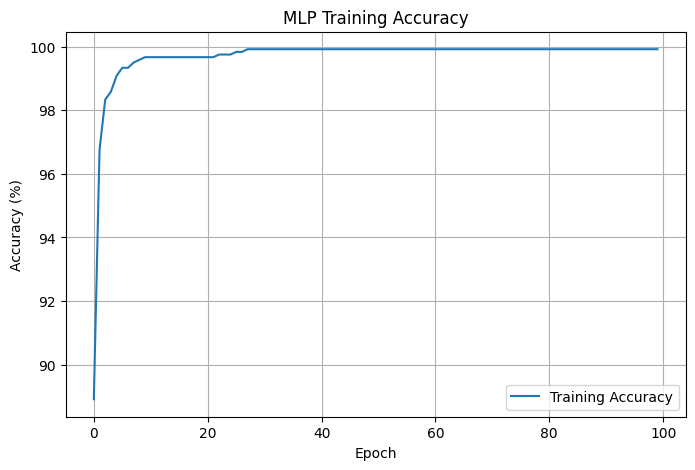

In [18]:
# ============================================================
# Training Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MLP Training Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Training Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.array(accuracy_history) * 100,
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("MLP Training Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# Numerical Gradient Checking

To verify that the manually derived backpropagation gradients are correct, numerical differentiation is used.

For a parameter \(\theta\):

\[
\frac{\partial L}{\partial \theta}
\approx
\frac{
L(\theta+\epsilon)
-
L(\theta-\epsilon)
}
{2\epsilon}
\]

The numerical gradient is compared with the analytical gradient obtained from our manually implemented backward propagation.

A small relative error indicates that the analytical gradient is correct.

In [19]:
# ============================================================
# Numerical Gradient Checking
# ============================================================

def numerical_gradient_check(
    X,
    Y,
    parameters,
    parameter_name="W1",
    epsilon=1e-5,
    num_checks=10
):

    # Analytical gradient
    predictions, activations, pre_activations = forward(
        X,
        parameters
    )

    analytical_gradients = backward(
        Y,
        predictions,
        activations,
        pre_activations,
        parameters
    )

    analytical_gradient = analytical_gradients[
        "d" + parameter_name
    ]

    parameter = parameters[
        parameter_name
    ]

    # Random parameter positions
    random_indices = np.random.choice(
        parameter.size,
        size=min(
            num_checks,
            parameter.size
        ),
        replace=False
    )

    numerical_values = []
    analytical_values = []

    for flat_index in random_indices:

        index = np.unravel_index(
            flat_index,
            parameter.shape
        )

        original_value = parameter[index]

        # theta + epsilon
        parameter[index] = (
            original_value + epsilon
        )

        prediction_plus, _, _ = forward(
            X,
            parameters
        )

        loss_plus = cross_entropy(
            Y,
            prediction_plus
        )

        # theta - epsilon
        parameter[index] = (
            original_value - epsilon
        )

        prediction_minus, _, _ = forward(
            X,
            parameters
        )

        loss_minus = cross_entropy(
            Y,
            prediction_minus
        )

        # Restore parameter
        parameter[index] = original_value

        numerical_gradient = (
            loss_plus - loss_minus
        ) / (2 * epsilon)

        numerical_values.append(
            numerical_gradient
        )

        analytical_values.append(
            analytical_gradient[index]
        )

    numerical_values = np.array(
        numerical_values
    )

    analytical_values = np.array(
        analytical_values
    )

    # Relative error
    numerator = np.linalg.norm(
        numerical_values
        - analytical_values
    )

    denominator = (
        np.linalg.norm(
            numerical_values
        )
        +
        np.linalg.norm(
            analytical_values
        )
        +
        1e-12
    )

    relative_error = (
        numerator / denominator
    )

    return relative_error


# Small batch for gradient checking
gradient_check_X = X_train[:8]
gradient_check_Y = Y_train[:8]

relative_error = numerical_gradient_check(
    gradient_check_X,
    gradient_check_Y,
    trained_parameters,
    parameter_name="W1"
)

print("========== GRADIENT CHECK ==========")
print(
    "Relative Error:",
    relative_error
)

if relative_error < 1e-5:
    print("Result: PASS")
elif relative_error < 1e-3:
    print("Result: ACCEPTABLE")
else:
    print("Result: FAILED")

========== GRADIENT CHECK ==========
Relative Error: 1.7288432929527661e-09
Result: PASS


# Conclusion

The fully connected Multi-Layer Perceptron was implemented completely from scratch using NumPy.

The implementation successfully demonstrates:

- Arbitrary hidden-layer dimensions
- Batch-wise vectorized forward propagation
- ReLU activation
- Softmax classification
- Categorical cross-entropy loss
- Manual backward propagation
- Layer-wise gradient computation
- 3D local Jacobian matrices
- Manual gradient-descent updates
- Mini-batch training
- Model evaluation
- Numerical gradient verification

No automatic differentiation or pre-built deep learning framework was used.

The decreasing loss, increasing accuracy, and successful gradient check demonstrate that the forward and backward mathematical operations have been implemented correctly.